# Colab Pytesseract OCR (T4 GPU Ortamı)

Bu notebook Colab üzerinde **Pytesseract** kullanarak OCR yapmak için hazırlanmıştır.

**Not:** Tesseract temel olarak CPU üzerinde çalışır ancak Colab'ın T4 GPU ortamında diğer görüntü işleme adımları (OpenCV vb.) için GPU avantajından yararlanabilirsiniz.

In [1]:
# 1. Tesseract OCR sistem motorunu ve Türkçe dil paketini kurun
!apt-get install -y tesseract-ocr tesseract-ocr-tur

# 2. Python wrapper'ını kurun
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-tur
0 upgraded, 1 newly installed, 0 to remove and 90 not upgraded.
Need to get 1,578 kB of archives.
After this operation, 4,565 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-tur all 1:4.00~git30-7274cfa-1.1 [1,578 kB]
Fetched 1,578 kB in 1s (1,288 kB/s)         
Selecting previously unselected package tesseract-ocr-tur.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-tur_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-tur (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-tur (1:4.00~git30-7274cfa-1.1) ...



--- OCR SONUCU ---

Universal segmentation model
valid masks
€. confidence
| score
| =e, —| Image |_» —)> lightweight confidence
” — = encoder mask decoder «©
a score
image T T T 3 , confidence
< score
image prompt encoder
embeddings
t
down  \ (x,y, fg/bg)
sample
| (X1,y1),(x2y2)
tT |
mask points box text


--- İŞLENEN GÖRSEL ---


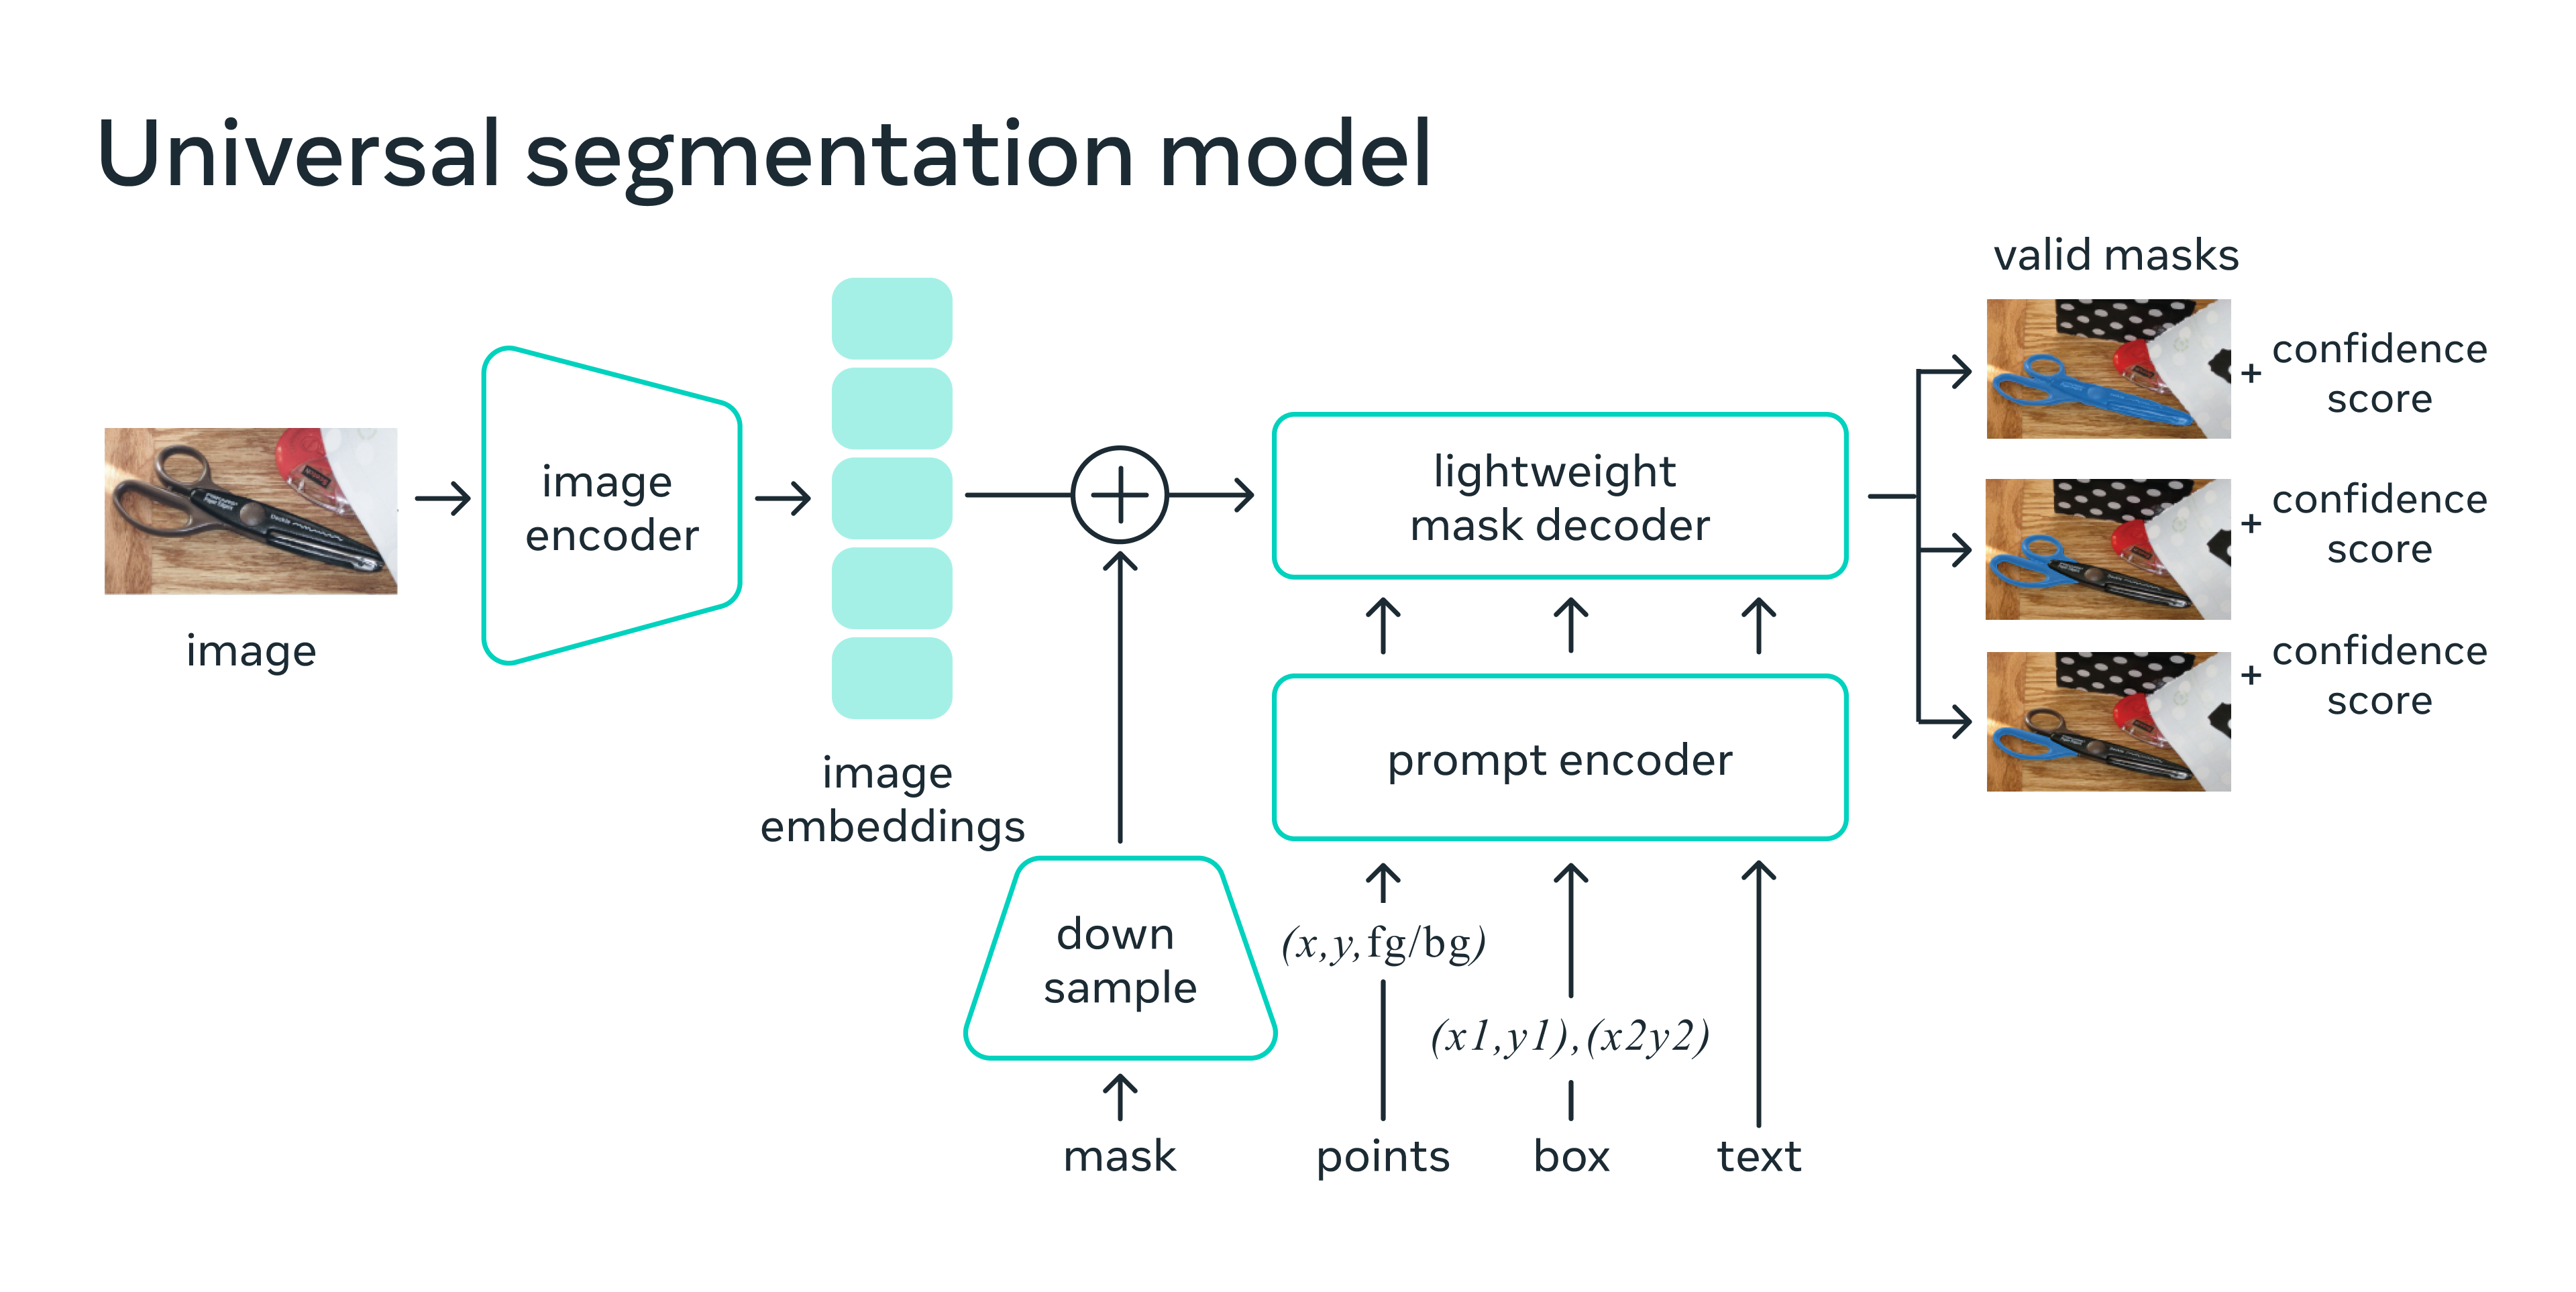

In [2]:
import pytesseract
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import os

# 3. OCR yapılacak resmin yolunu belirtin
image_path = 'arch.png' 

if os.path.exists(image_path):
    # 4. Resmi oku
    img = cv2.imread(image_path)
    
    # Tesseract için genelde gri tonlama veya eşikleme (thresholding) önerilir
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 5. Metni oku (Türkçe ve İngilizce desteği ile)
    # config kısmı daha iyi sonuçlar için optimize edilebilir
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(gray, lang='tur+eng', config=custom_config)

    print("\n--- OCR SONUCU ---\n")
    print(text)

    # 6. Resmi göster
    print("\n--- İŞLENEN GÖRSEL ---")
    cv2_imshow(img)
else:
    print(f"Hata: {image_path} bulunamadı. Lütfen resmi sol menüden yükleyin.")